In [43]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random

In [44]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [45]:
len([3,[3,4,5,6],6,7,[3,4,5,6],8])
len(x_train)

60000

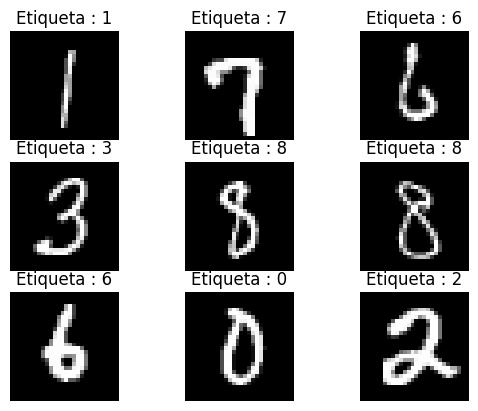

In [46]:
plt.figure()
for i in range(9):
    index = random.randint(0, len(x_train))
    plt.subplot(3,3, i + 1)
    plt.imshow(x_train[index], cmap='gray')
    plt.title(f"Etiqueta : {y_train[index]}")
    plt.axis('off')

plt.show()

In [47]:
# NORMALIZACION (0 - 255) ->  (0 - 1)
x_train = x_train / 255.0
x_test = x_test / 255.0

# FLATTEN 
# x_train.shape # 60000, 28, 28 -> 60000 , 28x28
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

In [48]:
# ONE-HOT ENCODING
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print(x_train.shape)
print(y_train.shape)

(60000, 784)
(60000, 10)


In [49]:
def crearModelo(inicializador):
    modelo = tf.keras.Sequential([
        tf.keras.layers.Dense(256, activation='relu', kernel_initializer=inicializador),
        tf.keras.layers.Dense(128, activation='relu', kernel_initializer=inicializador),
        tf.keras.layers.Dense(64, activation='relu', kernel_initializer=inicializador),
        tf.keras.layers.Dense(10, activation='softmax', kernel_initializer=inicializador)
    ])

    modelo.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return modelo

In [50]:
inicializadores = {
    "Zeros": tf.keras.initializers.Zeros(),
    "RandomNormal": tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.1),
    "HeNormal": tf.keras.initializers.HeNormal(),
}

historias = {}
modelos = {}

for name, inicializador in inicializadores.items():
    print(f"Entrenando con inicializador {name}")
    tf.keras.backend.clear_session()
    modelo = crearModelo(inicializador)

    modelo.build((None, 784))
    ejemploPesos = modelo.layers[1].get_weights()[0].flatten()[:10]
    print(f"Primeros 10 pesos: {ejemploPesos}")

    historia = modelo.fit(
        x_train, y_train,
        epochs=30,
        batch_size=128,
        validation_split=0.2,
        verbose=1
    )

    modelos[name] = modelo
    historias[name] = historia

Entrenando con inicializador Zeros
Primeros 10 pesos: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.1138 - loss: 2.3017 - val_accuracy: 0.1060 - val_loss: 2.3019
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3020
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3020
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1140 - loss: 2.3010 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1140 - loss: 2.3011 - val_accuracy: 0.1060 - val_loss: 2.3021
Epoch 8/30
375/375

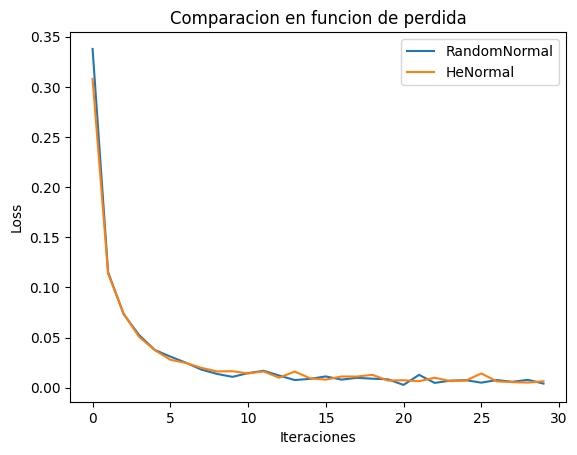

In [51]:
plt.figure()

# for nombre, historia in historias.items():
    # plt.plot(historias.history['loss'], label=nombre)
plt.plot(historias['RandomNormal'].history['loss'], label='RandomNormal')
plt.plot(historias['HeNormal'].history['loss'], label='HeNormal')
plt.title('Comparacion en funcion de perdida')
plt.xlabel('Iteraciones')
plt.ylabel('Loss')
plt.legend()
plt.show()

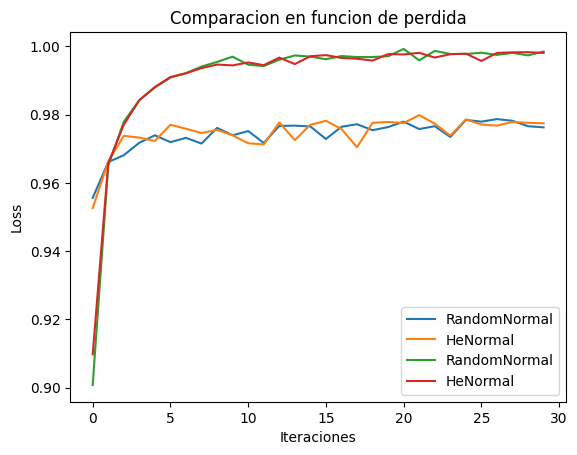

In [52]:
plt.figure()

# for nombre, historia in historias.items():
    # plt.plot(historia.history['val_accuracy'], label=nombre)
plt.plot(historias['RandomNormal'].history['val_accuracy'], label='RandomNormal')
plt.plot(historias['HeNormal'].history['val_accuracy'], label='HeNormal')
plt.plot(historias['RandomNormal'].history['accuracy'], label='RandomNormal')
plt.plot(historias['HeNormal'].history['accuracy'], label='HeNormal')
plt.title('Comparacion en funcion de perdida')
plt.xlabel('Iteraciones')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [53]:
mod1 = modelos['Zeros']
mod2 = modelos['RandomNormal']
mod3 = modelos['HeNormal']

In [54]:
tl1, ta1 = mod1.evaluate(x_test, y_test, verbose=1)
print(f"Perdida : {tl1}")
print(f"Precision : {ta1}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1135 - loss: 2.3010
Perdida : 2.3010330200195312
Precision : 0.11349999904632568


In [55]:
tl2, ta2 = mod2.evaluate(x_test, y_test, verbose=1)
print(f"Perdida : {tl2}")
print(f"Precision : {ta2}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9785 - loss: 0.1338
Perdida : 0.13375845551490784
Precision : 0.9785000085830688


In [56]:
tl3, ta3 = mod3.evaluate(x_test, y_test, verbose=1)
print(f"Perdida : {tl3}")
print(f"Precision : {ta3}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9801 - loss: 0.1109
Perdida : 0.11087758839130402
Precision : 0.9800999760627747


In [63]:
tf.keras.backend.clear_session()
modeloHe = tf.keras.Sequential([
	tf.keras.layers.Dense(64, activation='relu',
							kernel_initializer=tf.keras.initializers.HeNormal(),
							input_shape=(784,)),
	tf.keras.layers.Dense(32, activation='relu',
							kernel_initializer=tf.keras.initializers.HeNormal()),
	tf.keras.layers.Dense(16, activation='relu',
							kernel_initializer=tf.keras.initializers.HeNormal()),
	tf.keras.layers.Dense(10, activation='softmax', 
							kernel_initializer=tf.keras.initializers.HeNormal())
])

modeloHe.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

historiaHe = modeloHe.fit(
    x_train, y_train,
    epochs=30,
    batch_size = 128,
    validation_split = 0.2,
    verbose=1
)


c:\Users\franc\Documents\pythonEnv\dev\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7792 - loss: 0.6591 - val_accuracy: 0.9392 - val_loss: 0.2133
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9477 - loss: 0.1808 - val_accuracy: 0.9565 - val_loss: 0.1544
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9609 - loss: 0.1332 - val_accuracy: 0.9589 - val_loss: 0.1392
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9686 - loss: 0.1070 - val_accuracy: 0.9622 - val_loss: 0.1293
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9738 - loss: 0.0878 - val_accuracy: 0.9682 - val_loss: 0.1137
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9777 - loss: 0.0745 - val_accuracy: 0.9655 - val_loss: 0.1138
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9796 - loss: 0.0659 - val_accuracy: 0.9683 - val_loss: 0.1091
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9828 - loss: 0.0567 - val_accuracy: 0.

In [64]:
tf.keras.backend.clear_session()
modeloHeL2 = tf.keras.Sequential([
	tf.keras.layers.Dense(64, activation='relu',
							kernel_initializer=tf.keras.initializers.HeNormal(),
                            kernel_regularizer=tf.keras.regularizers.l2(0.001),
							input_shape=(784,)),
	tf.keras.layers.Dense(32, activation='relu',
							kernel_initializer=tf.keras.initializers.HeNormal(),
                            kernel_regularizer=tf.keras.regularizers.l2(0.001)),
	tf.keras.layers.Dense(16, activation='relu',
							kernel_initializer=tf.keras.initializers.HeNormal(),
                            kernel_regularizer=tf.keras.regularizers.l2(0.001)),
	tf.keras.layers.Dense(10, activation='softmax', 
							kernel_initializer=tf.keras.initializers.HeNormal())
])

modeloHeL2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

historiaHeL2 = modeloHeL2.fit(
    x_train, y_train,
    epochs=30,
    batch_size = 128,
    validation_split = 0.2,
    verbose=1
)


Epoch 1/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8286 - loss: 0.7439 - val_accuracy: 0.9352 - val_loss: 0.3888
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9435 - loss: 0.3481 - val_accuracy: 0.9559 - val_loss: 0.3021
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9557 - loss: 0.2948 - val_accuracy: 0.9572 - val_loss: 0.2811
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9631 - loss: 0.2629 - val_accuracy: 0.9609 - val_loss: 0.2705
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9670 - loss: 0.2410 - val_accuracy: 0.9631 - val_loss: 0.2501
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9701 - loss: 0.2270 - val_accuracy: 0.9652 - val_loss: 0.2387
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9731 - loss: 0.2148 - val_accuracy: 0.9678 - val_loss: 0.2304
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9736 - loss: 0.2066 - val_accuracy: 0.

In [76]:
tf.keras.backend.clear_session()
modeloHeL2Dr = tf.keras.Sequential([
	tf.keras.layers.Dense(64, activation='relu',
							kernel_initializer=tf.keras.initializers.HeNormal(),
                            kernel_regularizer=tf.keras.regularizers.l2(0.001),
							input_shape=(784,)),
    tf.keras.layers.Dropout(0.1),
	tf.keras.layers.Dense(32, activation='relu',
							kernel_initializer=tf.keras.initializers.HeNormal(),
                            kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.1),
	tf.keras.layers.Dense(16, activation='relu',
							kernel_initializer=tf.keras.initializers.HeNormal(),
                            kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.1),
	tf.keras.layers.Dense(10, activation='softmax', 
							kernel_initializer=tf.keras.initializers.HeNormal())
])

modeloHeL2Dr.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

historiaHeL2Dr = modeloHeL2Dr.fit(
    x_train, y_train,
    epochs=30,
    batch_size = 128,
    validation_split = 0.2,
    verbose=1
)


Epoch 1/30


c:\Users\franc\Documents\pythonEnv\dev\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7515 - loss: 0.9608 - val_accuracy: 0.9272 - val_loss: 0.4224
Epoch 2/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8971 - loss: 0.5113 - val_accuracy: 0.9456 - val_loss: 0.3424
Epoch 3/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9202 - loss: 0.4281 - val_accuracy: 0.9526 - val_loss: 0.3073
Epoch 4/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9324 - loss: 0.3786 - val_accuracy: 0.9579 - val_loss: 0.2816
Epoch 5/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9405 - loss: 0.3459 - val_accuracy: 0.9611 - val_loss: 0.2670
Epoch 6/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9450 - loss: 0.3241 - val_accuracy: 0.9635 - val_loss: 0.2546
Epoch 7/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9479 - loss: 0.3071 - val_accuracy: 0.9665 - val_loss: 0.2389
Epoch 8/30
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9510 - loss: 0.2941 - val_accuracy: 0.9682 - val_

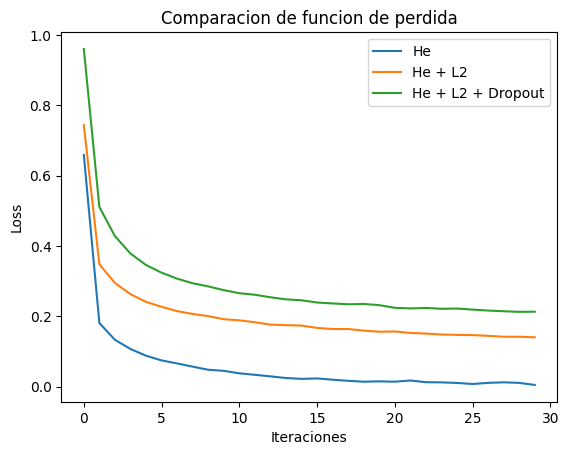

In [77]:
plt.figure()
plt.plot(historiaHe.history['loss'], label='He')
plt.plot(historiaHeL2.history['loss'],label='He + L2')
plt.plot(historiaHeL2Dr.history['loss'], label='He + L2 + Dropout')
plt.title('Comparacion de funcion de perdida')
plt.xlabel("Iteraciones")
plt.ylabel('Loss')
plt.legend()
plt.show()

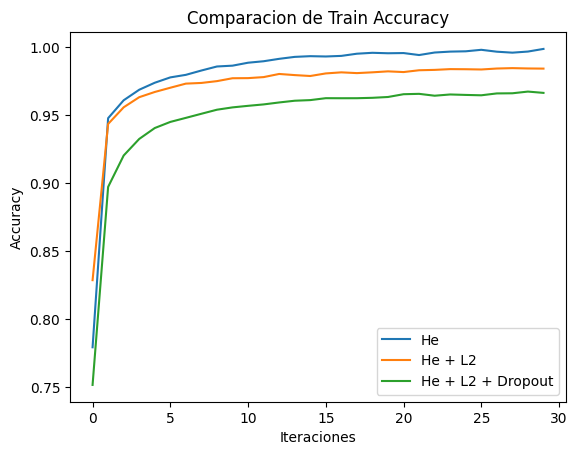

In [78]:
plt.figure()
plt.plot(historiaHe.history['accuracy'], label='He')
plt.plot(historiaHeL2.history['accuracy'],label='He + L2')
plt.plot(historiaHeL2Dr.history['accuracy'], label='He + L2 + Dropout')
plt.title('Comparacion de Train Accuracy')
plt.xlabel("Iteraciones")
plt.ylabel('Accuracy')
plt.legend()
plt.show()

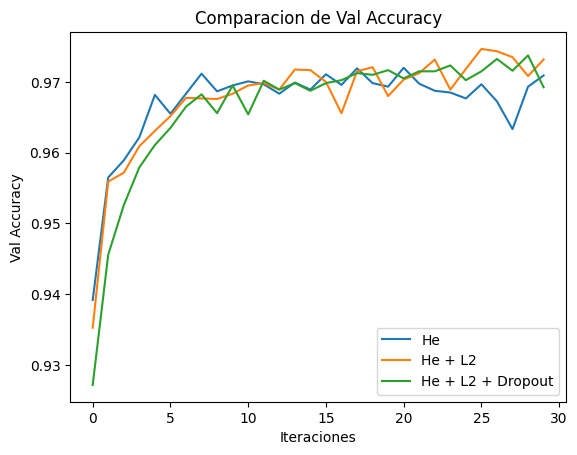

In [79]:
plt.figure()
plt.plot(historiaHe.history['val_accuracy'], label='He')
plt.plot(historiaHeL2.history['val_accuracy'],label='He + L2')
plt.plot(historiaHeL2Dr.history['val_accuracy'], label='He + L2 + Dropout')
plt.title('Comparacion de Val Accuracy')
plt.xlabel("Iteraciones")
plt.ylabel('Val Accuracy')
plt.legend()
plt.show()

In [80]:
tl1, ta1 = modeloHe.evaluate(x_test, y_test, verbose=1)
print(f"Perdida : {tl1}")
print(f"Precision : {ta1}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9731 - loss: 0.1462  
Perdida : 0.14621815085411072
Precision : 0.9731000065803528


In [81]:
tl2, ta2 = modeloHeL2.evaluate(x_test, y_test, verbose=1)
print(f"Perdida : {tl2}")
print(f"Precision : {ta2}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 961us/step - accuracy: 0.9780 - loss: 0.1616
Perdida : 0.16155125200748444
Precision : 0.9779999852180481


In [82]:
tl3, ta3 = modeloHeL2Dr.evaluate(x_test, y_test, verbose=1)
print(f"Perdida : {tl3}")
print(f"Precision : {ta3}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 889us/step - accuracy: 0.9727 - loss: 0.1877
Perdida : 0.18770289421081543
Precision : 0.9726999998092651


In [83]:
tf.keras.backend.clear_session()
modeloHeL2_v2 = tf.keras.Sequential([
	tf.keras.layers.Dense(64, activation='relu',
							kernel_initializer=tf.keras.initializers.HeNormal(),
                            kernel_regularizer=tf.keras.regularizers.l2(0.001),
							input_shape=(784,)),
	tf.keras.layers.Dense(32, activation='relu',
							kernel_initializer=tf.keras.initializers.HeNormal(),
                            kernel_regularizer=tf.keras.regularizers.l2(0.001)),
	tf.keras.layers.Dense(16, activation='relu',
							kernel_initializer=tf.keras.initializers.HeNormal(),
                            kernel_regularizer=tf.keras.regularizers.l2(0.001)),
	tf.keras.layers.Dense(10, activation='softmax', 
							kernel_initializer=tf.keras.initializers.HeNormal())
])

modeloHeL2_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
	monitor='val_loss',
	factor=0.5,
	patience=4,
	min_lr=1e-6,
	verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
	monitor='val_loss',
	patience=8, 
	restore_best_weights=True,
	verbose=1
)

historiaHeL2_v2 = modeloHeL2_v2.fit(
    x_train, y_train,
    epochs=400,
    batch_size = 128,
    validation_split = 0.2,
    callbacks=[reduce_lr, early_stop],
    verbose=1
)


c:\Users\franc\Documents\pythonEnv\dev\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/400
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8197 - loss: 0.7580 - val_accuracy: 0.9327 - val_loss: 0.3828 - learning_rate: 0.0010
Epoch 2/400
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9419 - loss: 0.3436 - val_accuracy: 0.9499 - val_loss: 0.3102 - learning_rate: 0.0010
Epoch 3/400
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9547 - loss: 0.2877 - val_accuracy: 0.9600 - val_loss: 0.2705 - learning_rate: 0.0010
Epoch 4/400
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9638 - loss: 0.2526 - val_accuracy: 0.9608 - val_loss: 0.2628 - learning_rate: 0.0010
Epoch 5/400
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9668 - loss: 0.2361 - val_accuracy: 0.9632 - val_loss: 0.2474 - learning_rate: 0.0010
Epoch 6/400
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9701 - loss: 0.2219 - val_accuracy: 0.9662 - val_loss: 0.2340 - learning_rate: 0.0010
Epoch 7/400
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9721 - loss: 0.

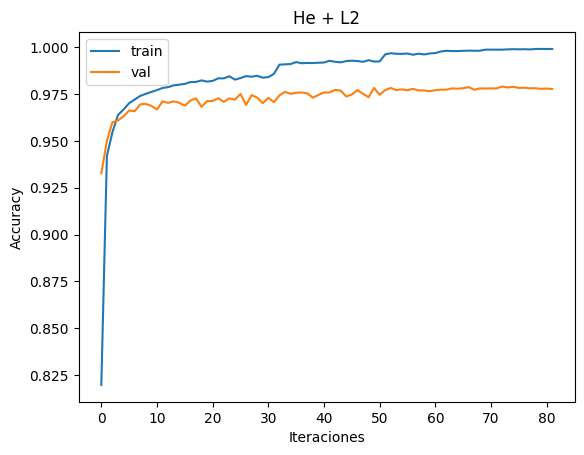

In [84]:
plt.figure()
plt.plot(historiaHeL2_v2.history['accuracy'], label='train')
plt.plot(historiaHeL2_v2.history['val_accuracy'], label='val')

plt.title("He + L2")
plt.xlabel('Iteraciones')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [85]:
tl4, ta4 = modeloHeL2_v2.evaluate(x_test, y_test, verbose=1)
print(f"Perdida : {tl4}")
print(f"Precision : {ta4}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9787 - loss: 0.1347
Perdida : 0.13472980260849
Precision : 0.9786999821662903


In [86]:
tf.keras.backend.clear_session()
modeloHeL2Dr_v2 = tf.keras.Sequential([
	tf.keras.layers.Dense(64, activation='relu',
							kernel_initializer=tf.keras.initializers.HeNormal(),
                            kernel_regularizer=tf.keras.regularizers.l2(0.001),
							input_shape=(784,)),
    tf.keras.layers.Dropout(0.1),
	tf.keras.layers.Dense(32, activation='relu',
							kernel_initializer=tf.keras.initializers.HeNormal(),
                            kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.1),
	tf.keras.layers.Dense(16, activation='relu',
							kernel_initializer=tf.keras.initializers.HeNormal(),
                            kernel_regularizer=tf.keras.regularizers.l2(0.001)),
    tf.keras.layers.Dropout(0.1),
	tf.keras.layers.Dense(10, activation='softmax', 
							kernel_initializer=tf.keras.initializers.HeNormal())
])

modeloHeL2Dr_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
	monitor='val_loss',
	factor=0.5,
	patience=4,
	min_lr=1e-6,
	verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
	monitor='val_loss',
	patience=8, 
	restore_best_weights=True,
	verbose=1
)

historiaHeL2Dr_v2 = modeloHeL2Dr_v2.fit(
    x_train, y_train,
    epochs=400,
    batch_size = 128,
    validation_split = 0.2,
    callbacks=[reduce_lr, early_stop],
    verbose=1
)


Epoch 1/400


c:\Users\franc\Documents\pythonEnv\dev\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7549 - loss: 0.9439 - val_accuracy: 0.9283 - val_loss: 0.4170 - learning_rate: 0.0010
Epoch 2/400
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9028 - loss: 0.5004 - val_accuracy: 0.9448 - val_loss: 0.3412 - learning_rate: 0.0010
Epoch 3/400
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9235 - loss: 0.4184 - val_accuracy: 0.9578 - val_loss: 0.2994 - learning_rate: 0.0010
Epoch 4/400
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9347 - loss: 0.3729 - val_accuracy: 0.9594 - val_loss: 0.2818 - learning_rate: 0.0010
Epoch 5/400
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9413 - loss: 0.3441 - val_accuracy: 0.9601 - val_loss: 0.2723 - learning_rate: 0.0010
Epoch 6/400
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9447 - loss: 0.3240 - val_accuracy: 0.9644 - val_loss: 0.2557 - learning_rate: 0.0010
Epoch 7/400
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9471 - loss: 0.3107 - val_a

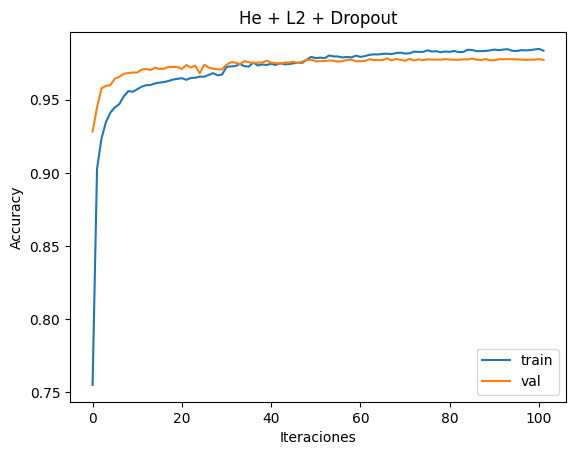

In [87]:
plt.figure()
plt.plot(historiaHeL2Dr_v2.history['accuracy'], label='train')
plt.plot(historiaHeL2Dr_v2.history['val_accuracy'], label='val')

plt.title("He + L2 + Dropout")
plt.xlabel('Iteraciones')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [88]:
tl5, ta5 = modeloHeL2Dr_v2.evaluate(x_test, y_test, verbose=1)
print(f"Perdida : {tl5}")
print(f"Precision : {ta5}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9781 - loss: 0.1477  
Perdida : 0.14770767092704773
Precision : 0.9781000018119812
